# 03 - Kernel cuántico

Construimos un circuito con Pytket y calculamos una matriz de kernel pequeña.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'main.py').exists())
sys.path.insert(0, str(ROOT))
from prepare_data import load_data
from quantum_model import balanced_subset, preprocess_subset, build_feature_map, quantum_kernel

X_train, X_test, y_train, y_test = load_data(ROOT / 'data/raw/water_potability.csv')
X_small, y_small = balanced_subset(X_train, y_train, 16, 2026)
X_scaled, _ = preprocess_subset(X_small, X_small)
circuit = build_feature_map(X_scaled[0], 'custom', 2)
print('Qubits:', circuit.n_qubits)
print('Profundidad:', circuit.depth())
print('Compuertas:', len(circuit.get_commands()))

Qubits: 9
Profundidad: 14
Compuertas: 52


Simétrica: True
Diagonal igual a 1: True


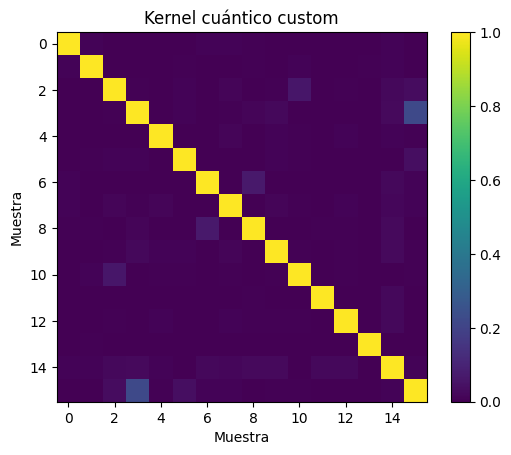

In [2]:
kernel = quantum_kernel(X_scaled, name='custom', repetitions=2)
print('Simétrica:', np.allclose(kernel, kernel.T))
print('Diagonal igual a 1:', np.allclose(np.diag(kernel), 1))

plt.imshow(kernel, vmin=0, vmax=1, cmap='viridis')
plt.colorbar()
plt.title('Kernel cuántico custom')
plt.xlabel('Muestra')
plt.ylabel('Muestra')
plt.show()